In [2]:
#Thư viện:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#data train, test:
#train:
df = pd.read_csv("data/fashion-mnist_train.csv")
#test:
df_test = pd.read_csv("data/fashion-mnist_test.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#Tạo label số tương ứng với trang phục 
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

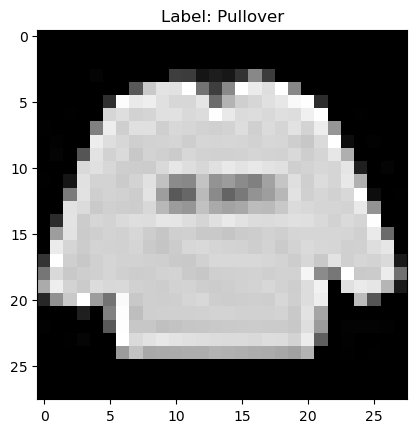

In [6]:
image = df.iloc[0, 1:].to_numpy().reshape(28, 28) # chỉnh hình về dạng 28x28 pixels
image_label = fashion_mnist_labels[df.iloc[0, 0]]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {image_label}")
plt.show()

In [7]:
# Chuẩn hoá giá trị pixel từ phạm vi (0-255) đến (0-1):
X = df.iloc[:, 1:] / 255.0
y = df.iloc[:, 0]

X_test = df_test.iloc[:, 1:] / 255.0
y_test = df_test.iloc[:, 0]

In [8]:
# Định dạng hình ảnh để phù hợp với mô hình CNN:
X = X.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

In [9]:
#Mã hoá nhãn bằng LabelEncoder:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y_test = label_encoder.transform(y_test)

In [10]:
from sklearn.model_selection import train_test_split

# Split data into training, validation, and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Display dataset shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("===================================")
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (38400, 28, 28, 1)
X_val shape: (9600, 28, 28, 1)
X_test shape: (12000, 28, 28, 1)
y_train shape: (38400,)
y_val shape: (9600,)
y_test shape: (12000,)


In [11]:
#Xây dựng mô hình CNN
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    # tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

2025-03-19 15:45:39.501129: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
#cấu hình mô hình:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
#Train mô hình:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))

Epoch 1/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 150s 119ms/step - accuracy: 0.6782 - loss: 0.9536 - val_accuracy: 0.8592 - val_loss: 0.4013
Epoch 2/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 153s 127ms/step - accuracy: 0.8390 - loss: 0.4459 - val_accuracy: 0.8888 - val_loss: 0.3148
Epoch 3/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 152s 126ms/step - accuracy: 0.8659 - loss: 0.3729 - val_accuracy: 0.8794 - val_loss: 0.3304
Epoch 4/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 143s 119ms/step - accuracy: 0.8746 - loss: 0.3469 - val_accuracy: 0.8898 - val_loss: 0.3027
Epoch 5/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 119s 99ms/step - accuracy: 0.8858 - loss: 0.3190 - val_accuracy: 0.9045 - val_loss: 0.2663
Epoch 6/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 124s 103ms/step - accuracy: 0.8893 - loss: 0.3083 - val_accuracy: 0.9056 - val_loss: 0.2631
Epoch 7/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 121s 101ms/step - accuracy: 0.8947 - loss: 0.2903 - val_accuracy: 0.9137 - val_loss: 0.2433
Epoch 8/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 114s 95ms/step - accu

In [14]:
#Đánh giá mô hình:
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9342 - loss: 0.2046
Test accuracy: 0.9325000047683716


In [ ]:
# Vẽ biểu đồ loss
plt.figure(figsize=(8, 5))  # Tạo khung hình kích thước 8x5
plt.plot(range(1, 6), test_loss, marker='o')  # Vẽ đường mất mát qua 5 epoch, thêm điểm đánh dấu
plt.title("Biểu đồ mất mát qua các epoch")  # Tiêu đề biểu đồ
plt.xlabel("Epoch")  # Nhãn trục x
plt.ylabel("Loss")  # Nhãn trục y
plt.grid(True)  # Thêm lưới để dễ nhìn
plt.show()  # Hiển thị biểu đồ

In [1]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Testing Accuracy')
plt.show()

NameError: name 'plt' is not defined